In [11]:
import pandas as pd 
df = pd.read_table("sunlimeng_focus.txt")
df

,sgRNA ID,Gene ID,Focused-CRISPR_Read1_norm,Focused-CRISPR_Read2_norm,average(Focused-CRISPR),TGEV_3rd_Read1_norm,TGEV_3rd_Read2_norm,average(TGEV_3rd),Fold_change(TGEV_3rd),log2Foldchange(TGEV_3rd),TGEV_5th_Read1_norm,TGEV_5th_Read2_norm,average(TGEV_5th),Fold_change(TGEV_5th),log2Foldchange(TGEV_5th)
0,ENSSSCG00000002283_7_95991165_95991194_p,ENSSSCG00000002283,26564.05,24902.02,25733.04,494271.93,469530.91,481901.42,18.73,4.23,645147.64,612794.92,628971.28,24.44,4.61
1,ENSSSCG00000002283_7_95991173_95991202_m,ENSSSCG00000002283,22155.69,21505.61,21830.65,460343.94,428503.88,444423.91,20.36,4.35,532759.73,500519.37,516639.55,23.67,4.56
2,ENSSSCG00000002283_7_96009580_96009609_m,ENSSSCG00000002283,24329.55,24122.72,24226.13,392624.15,389318.95,390971.55,16.14,4.01,495895.89,475974.30,485935.09,20.06,4.33
3,ENSSSCG00000002283_7_95940504_95940533_m,ENSSSCG00000002283,23659.19,21716.18,22687.69,351332.95,330279.14,340806.05,15.02,3.91,392836.62,377869.23,385352.92,16.99,4.09
4,ENSSSCG00000002283_7_95991396_95991425_p,ENSSSCG00000002283,14311.50,14516.31,14413.90,227171.27,228559.49,227865.38,15.81,3.98,282416.77,287199.17,284807.97,19.76,4.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
774,ENSSSCG00000030478_5_93592786_93592815_p,ENSSSCG00000030478,3985.94,3381.37,3683.66,10.48,8.60,9.54,0.00,-8.59,0.00,2.72,1.36,0.00,-11.40
775,ENSSSCG00000026009_5_66003069_66003098_m,ENSSSCG00000026009,1174.71,1323.60,1249.15,0.00,0.96,0.48,0.00,-11.35,28.80,29.90,29.35,0.02,-5.41
776,ENSSSCG00000014587_9_1656135_1656164_p,ENSSSCG00000014587,527.77,486.95,507.36,0.00,0.00,0.00,0.00,#NUM!,0.00,0.00,0.00,0.00,#NUM!
777,ENSSSCG00000011266_13_26391447_26391476_p,ENSSSCG00000011266,709.72,715.38,712.55,0.00,0.00,0.00,0.00,#NUM!,0.00,0.00,0.00,0.00,#NUM!


In [12]:
def id():
    idList = []
    df = pd.read_table("sunlimeng_focus.txt")
    for _,row in df.iterrows():
        id = row["sgRNA ID"].split("_")
        idList.append(id[0])
    return idList

In [13]:
df["geneid"] = id()
df["geneid"].to_csv("focusall.txt", sep="\t", header=None, index=None)

In [4]:
gene = pd.read_table("../../rna-seq/00.diff/ctl-exp.tsv")
gene.columns = ["geneid","baseMean","log2FoldChange","lfcSE","stat","pvalue","padj"]
gene

,geneid,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSSSCG00000000002,63.002392,-0.308150,0.328892,-0.936935,3.487923e-01,5.135374e-01
1,ENSSSCG00000000003,38.995692,-0.235587,0.422692,-0.557350,5.772881e-01,7.157913e-01
2,ENSSSCG00000000005,23.174388,0.632312,0.489968,1.290517,1.968712e-01,3.438576e-01
3,ENSSSCG00000000006,29.874874,-0.010760,0.444249,-0.024221,9.806760e-01,9.894972e-01
4,ENSSSCG00000000007,76.945128,0.339734,0.277949,1.222287,2.215992e-01,3.741391e-01
...,...,...,...,...,...,...,...
19826,ENSSSCG00000051791,2.054076,0.703144,1.645976,0.427190,6.692409e-01,NaN
19827,ENSSSCG00000051793,0.789232,-2.834013,2.738001,-1.035066,3.006380e-01,NaN
19828,ENSSSCG00000051794,276.605891,0.509923,0.166904,3.055181,2.249244e-03,9.123363e-03
19829,ENSSSCG00000051795,23.144970,-4.811001,0.854785,-5.628317,1.819763e-08,2.179243e-07


In [5]:
df_out = pd.merge(df, gene, on="geneid")
df_out

,sgRNA ID,Gene ID,Focused-CRISPR_Read1_norm,Focused-CRISPR_Read2_norm,average(Focused-CRISPR),TGEV_3rd_Read1_norm,TGEV_3rd_Read2_norm,average(TGEV_3rd),Fold_change(TGEV_3rd),log2Foldchange(TGEV_3rd),...,average(TGEV_5th),Fold_change(TGEV_5th),log2Foldchange(TGEV_5th),geneid,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSSSCG00000002283_7_95991165_95991194_p,ENSSSCG00000002283,26564.05,24902.02,25733.04,494271.93,469530.91,481901.42,18.73,4.23,...,628971.28,24.44,4.61,ENSSSCG00000002283,296.178448,-0.898721,0.156035,-5.759735,8.424620e-09,1.066207e-07
1,ENSSSCG00000002283_7_95991173_95991202_m,ENSSSCG00000002283,22155.69,21505.61,21830.65,460343.94,428503.88,444423.91,20.36,4.35,...,516639.55,23.67,4.56,ENSSSCG00000002283,296.178448,-0.898721,0.156035,-5.759735,8.424620e-09,1.066207e-07
2,ENSSSCG00000002283_7_96009580_96009609_m,ENSSSCG00000002283,24329.55,24122.72,24226.13,392624.15,389318.95,390971.55,16.14,4.01,...,485935.09,20.06,4.33,ENSSSCG00000002283,296.178448,-0.898721,0.156035,-5.759735,8.424620e-09,1.066207e-07
3,ENSSSCG00000002283_7_95940504_95940533_m,ENSSSCG00000002283,23659.19,21716.18,22687.69,351332.95,330279.14,340806.05,15.02,3.91,...,385352.92,16.99,4.09,ENSSSCG00000002283,296.178448,-0.898721,0.156035,-5.759735,8.424620e-09,1.066207e-07
4,ENSSSCG00000002283_7_95991396_95991425_p,ENSSSCG00000002283,14311.50,14516.31,14413.90,227171.27,228559.49,227865.38,15.81,3.98,...,284807.97,19.76,4.30,ENSSSCG00000002283,296.178448,-0.898721,0.156035,-5.759735,8.424620e-09,1.066207e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,ENSSSCG00000030478_5_93584635_93584664_m,ENSSSCG00000030478,3448.59,3648.35,3548.47,416.92,425.39,421.16,0.12,-3.07,...,410.69,0.12,-3.11,ENSSSCG00000030478,173.612340,0.235170,0.198701,1.183537,2.365965e-01,3.917813e-01
376,ENSSSCG00000030478_5_93592799_93592828_m,ENSSSCG00000030478,4317.92,4835.64,4576.78,383.40,350.83,367.12,0.08,-3.64,...,298.53,0.07,-3.94,ENSSSCG00000030478,173.612340,0.235170,0.198701,1.183537,2.365965e-01,3.917813e-01
377,ENSSSCG00000030478_5_93584646_93584675_m,ENSSSCG00000030478,4341.33,4892.98,4617.16,160.27,169.20,164.74,0.04,-4.81,...,26.93,0.01,-7.42,ENSSSCG00000030478,173.612340,0.235170,0.198701,1.183537,2.365965e-01,3.917813e-01
378,ENSSSCG00000030478_5_93592785_93592814_p,ENSSSCG00000030478,7139.79,5948.66,6544.22,13.62,7.65,10.63,0.00,-9.27,...,1.91,0.00,-11.74,ENSSSCG00000030478,173.612340,0.235170,0.198701,1.183537,2.365965e-01,3.917813e-01


Text(0.5, 1.0, 'focus')

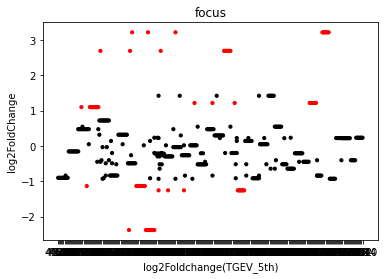

In [6]:
import matplotlib.pyplot as plt
import numpy as np

colors = np.where((df_out["pvalue"] < 0.05)  & (df_out["log2FoldChange"] >1)|(df_out["log2FoldChange"] <-1), 'r', 'k')
plt.scatter(df_out["log2Foldchange(TGEV_5th)"], df_out["log2FoldChange"], s=10, c=colors)
plt.ylabel("log2FoldChange")
plt.xlabel("log2Foldchange(TGEV_5th)")
plt.title("focus")

#bx = df_out.plot(kind='scatter', x='log2Foldchange(TGEV_5th)',y='log2FoldChange',color = 'Green',label ='gene')
#bx

In [7]:
df_out[(df_out["pvalue"] < 0.05)  & (df_out["log2FoldChange"] >1)].shape

(40, 22)

In [8]:
(380-40)/380

0.8947368421052632

In [10]:
df_geneid = df_out.drop_duplicates(subset='geneid')
df_geneid["Gene ID"].to_csv("focus.txt", sep="\t", header=None, index=None)

In [16]:
#df_out[(df_out["pvalue"] < 0.05)  & (df_out["log2FoldChange"] >1)].drop_duplicates(subset='geneid')